# TDA-JC and TDA-PF models for multi-systems application

**Created by:** Khang Luong  
**Department of Chemistry, Brandeis University**
#### **Referecne:** _[put reference here later]_
--- 
## Overview
This tutorial covers the applications of Tamm-Dancoff approximation with Jaynes-Cummings and Pauli-Fierz (TDA-JC and TDA-PF) in a system of many molecules. 

By the end of this tutorial, you will be able to:
1. **Part 1-** Understand the theoretical framework of TDA-JC and TDA-PF in multi-system configurations
2. **Part 2-** Computationally apply ```qed``` package to model them

---
# Environment Setup
Please review Lesson 1 notebook for specific requirements. After that, execute the cell below to confirm that the environment is configured correctly.

### 📦 Import and & Configuration

In [119]:
import numpy as np
from pyscf import gto, scf, tdscf
import scipy
import qed
from qed.tdscf.ghf import FewLevel # We need to this to run JC and PF for multiple systems
#pip install qed later. 
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Color for printing
RED    = "\033[91m"
GREEN  = "\033[92m"
YELLOW = "\033[93m"
BLUE   = "\033[94m"
RESET  = "\033[0m"

#Unit Conversion:
HF_TO_EV = 27.2114
EV_TO_HF = 1 / HF_TO_EV

print("✅ All the imports are successful!")

✅ All the imports are successful!


---
# 🗂️ Part 1: Theoretical Framework

---
# Part 2: How to implement
## 2.1 Define Multiple Molecules
Instead of one, you will define a list of geometries. For simplicity, we can use two ethene molecules at differnt positions (feel free to change them if you like)

In [120]:
geom1 = 'H -0.945 0.0 1.128; C 0.0 0.0 0.526; H 0.945 0.0 1.128; O 0.0 0.0 -0.677'
geom2 = 'H -0.945 10.0 1.128; C 0.0 10.0 0.526; H 0.945 10.0 1.128; O 0.0 10.0 -0.677'

geoms = [geom1, geom2]
mfs = []
tds = []

# Run electronic ground state and TDDFT for each molecule
for g in geoms:
    mol = gto.M(atom=g, basis='6-311++G')
    mf = scf.RKS(mol)
    mf.xc = 'pbe0'
    mf.kernel()

    td = tdscf.TDA(mf)
    td.nroots = 10
    td.kernel()

    mfs.append(mf)
    tds.append(td)

converged SCF energy = -114.361869449636
Excitation energies (eV)
[ 3.88373633  6.8047454   7.78074553  7.91209213  8.56941276  9.16570272
  9.76183175  9.969099   10.30385346 10.50729248]
converged SCF energy = -114.361869449636
Excitation energies (eV)
[ 3.88373633  6.8047454   7.78074553  7.91209213  8.56941276  9.16570272
  9.76183175  9.969099   10.30385346 10.50729248]


## 2.2 Setup the Collective Cavity
Here, we follow the same procedures as previous lessons. Please note that the cavity is shared by all molecules so we don't need a separate key for each of them. 

In [121]:
cavity_freq = np.array([0.294])
cavity_mode = np.array([[0.01], [0.0], [0.0]]) # 3x1 vector for x-polarized coupling

key = {
    'cavity_freq': cavity_freq,
    'cavity_mode': cavity_mode
}

# Initialize JC or PF model for the collective system
cav_jc = qed.JC(mfs, key)
cav_pf = qed.PF(mfs, key)

scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2


## 2.3 Run Few-Level QED-TDA
For many molecules, the **Few-Level** approximation is the most efficient way to see collective effects.

In [122]:
# 1. Initialize the Few-Level solver 
qed_few = FewLevel(tds, cav_jc, key)
qed_few.cavity_model = 'JC' # or 'PF'
qed_few.nstates = 5 # number of state to solve for
qed_few.target_states = 'polariton'
qed_few.solver_algorithm = 'direct'
qed_few.solver_conv_prop = 'norm'
qed_few.level_shift = 0.0
qed_few.tolerance = 1e-8
qed_few.max_cycle = 100


# 2. Solve for collective polaritons
energies, vectors, trans_dips, mag_dip = qed_few.kernel()

# 3. Analyze Photon vs Electron character
weight_p, weight_e = qed_few.get_weights(vectors)

print(f"{'State':<6} {'Energy (eV)':<12} {'Photon %':<10}")
for i in range(len(energies)):
    print(f"{i+1:<6} {energies[i]*HF_TO_EV:<12.4f} {weight_p[i]*100:<10.2f}")
    

has_offdiag inter-fragment coupling? False
resonance_state: 4
has_offdiag inter-fragment coupling? False
State  Energy (eV)  Photon %  
1      3.8837       0.00      
2      3.8837       0.00      
3      6.7996       0.43      
4      6.8047       0.00      
5      7.7807       0.00      


## 2.4 Advanced: Inter-fragment Coupling
If you want to include dipole-dipole interactions between the molecules (not just their interaction with the cavity), you can set ```has_offdiag```:

In [123]:
qed_few.has_offdiag = True
energies_inter, _, _, _ = qed_few.kernel()

print(f"{'State':<6} {'Energy (eV)':<12}")
for i in range(len(energies_inter)):
    print(f"{i+1:<6} {energies_inter[i]*HF_TO_EV:<12.4f}")

has_offdiag inter-fragment coupling? True
State  Energy (eV) 
1      3.8837      
2      3.8837      
3      6.8008      
4      6.8036      
5      7.7795      


# 📊 Part 3: Energies vs Coupling for Multi-Systems

Here, we want to apply to a system of 10 molecules

scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
has_offdiag inter-fragment coupling? False
resonance_state: 1
has_offdiag inter-fragment coupling? False
scf_type: RKS
occupa

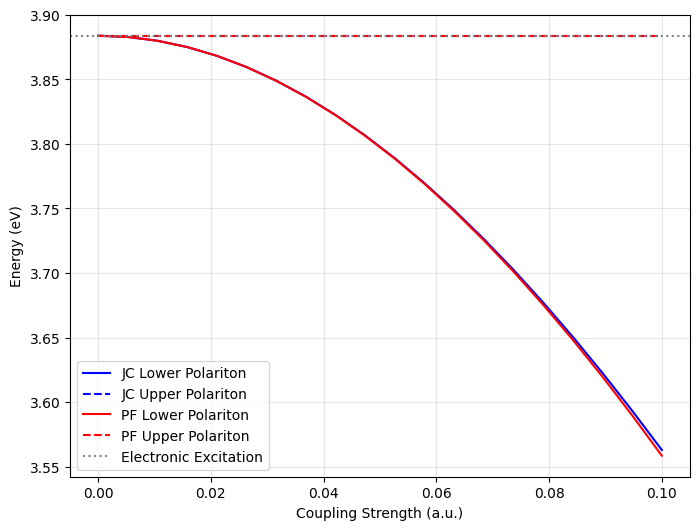

[3.88373833 3.88373833 3.88373833 3.88373833 3.88373833 3.88373833
 3.88373833 3.88373833 3.88373833 3.88373833 3.88373833 3.88373833
 3.88373833 3.88373833 3.88373833 3.88373833 3.88373833 3.88373833
 3.88373833 3.88373833]


In [ ]:
n_mols = 10
lambdas = np.linspace(0.0, 0.10, 20)
target_freq = tds[0].e[0] # Tune to the first electronic excitation

# Replicate the single-molecule results for the collective model
rep_tds = [tds[0]] * n_mols
rep_mfs = [mfs[0]] * n_mols

jc_energies = []
pf_energies = []

for lam in lambdas:
    current_key = key.copy()
    current_key['cavity_freq'] = np.array([target_freq])
    current_key['cavity_mode'] = np.array([[lam], [0.0], [0.0]])
    current_key['scale_coupling'] = 0 

    
    # 1. Setup cavity object
    cav_jc = qed.JC(rep_mfs, current_key)
    cav_pf = qed.PF(rep_mfs, current_key)

    # 2. Apply JC model
    sol_jc = FewLevel(rep_tds, cav_jc, current_key)
    sol_jc.cavity_model = 'JC'
    sol_jc.nstates = 20
    sol_jc.target_states = 'polariton'
    sol_jc.solver_algorithm = 'direct'
    sol_jc.solver_conv_prop = 'norm'
    sol_jc.level_shift = 0.0
    sol_jc.tolerance = 1e-8
    sol_jc.max_cycle = 100

    e_jc, _, _, _ = sol_jc.kernel()
    jc_energies.append(np.sort(e_jc)[:5]) # Keep lowest 5 states

    # 3. Apply PF model
    sol_pf = FewLevel(rep_tds, cav_pf, current_key)
    sol_pf.cavity_model = 'PF'
    sol_pf.nstates = 20
    sol_pf.target_states = 'polariton'
    sol_pf.solver_algorithm = 'direct'
    sol_pf.solver_conv_prop = 'norm'
    sol_pf.level_shift = 0.0
    sol_pf.tolerance = 1e-8
    sol_pf.max_cycle = 100

    e_pf, _, _, _ = sol_pf.kernel()
    pf_energies.append(np.sort(e_pf)[:5])

jc_energies = np.array(jc_energies) * HF_TO_EV
pf_energies = np.array(pf_energies) * HF_TO_EV

plt.figure(figsize=(8, 6))
plt.plot(lambdas, jc_energies[:, 0], 'b-', label='JC Lower Polariton')
plt.plot(lambdas, jc_energies[:, 1], 'b--', label='JC Upper Polariton')
plt.plot(lambdas, pf_energies[:, 0], 'r-', label='PF Lower Polariton')
plt.plot(lambdas, pf_energies[:, 1], 'r--', label='PF Upper Polariton')
plt.axhline(y=tds[0].e[0]*HF_TO_EV, color='gray', linestyle=':', label='Electronic Excitation')
plt.xlabel('Coupling Strength (a.u.)')
plt.ylabel('Energy (eV)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(jc_energies[:, 1])